# Physics-Informed Molecular ML for Protein–Ligand Energetics
## A portfolio-grade, reproducible drug-discovery project bridging quantum chemistry, molecular descriptors, PyTorch, uncertainty quantification, and production engineering

**Purpose.** This notebook is designed as a strong portfolio project for a Machine Learning Scientist / Senior Machine Learning Scientist role in quantum chemistry and small-molecule drug discovery. It demonstrates how a scientist can combine:

- molecular and medicinal-chemistry reasoning,
- simulated quantum-chemical observables,
- low-fidelity → high-fidelity **Δ-learning**,
- protein–ligand affinity modelling,
- leakage-aware validation,
- PyTorch modelling,
- uncertainty and applicability-domain analysis,
- interfaces for **xTB, Psi4, PySCF and ORCA**,
- and production-minded model persistence and QC.

> **Important scientific statement:** the dataset generated below is **synthetic**. Its property ranges and performance targets are benchmarked against peer-reviewed literature indexed in PubMed, but no row is presented as an experimentally measured molecule or protein–ligand complex. The purpose is reproducible methods demonstration, not biological or medicinal claims.

## 1. Why this project is strategically useful

The project deliberately addresses several capability areas simultaneously:

| Capability | Evidence in this notebook |
|---|---|
| Scientific research | Explicit hypotheses, literature benchmarks, validation, interpretation |
| Machine learning | Linear baselines, tree ensembles, gradient boosting, PyTorch MLP |
| Python | End-to-end data generation, modelling, QC, visualization, serialization |
| Drug discovery | Drug-like descriptors, protein–ligand interaction features, pKd prediction |
| Protein–ligand modelling | Interaction terms, affinity prediction, protein-family holdout |
| Linear algebra / probability / optimisation | scaling, gradient descent, uncertainty, Mahalanobis distance |
| PyTorch | trained neural network with early model-selection logic |
| JAX | optional autodiff demonstration if installed |
| Quantum chemistry | HOMO/LUMO, gap, dipole, energy, Δ-learning |
| xTB / Psi4 / PySCF / ORCA | executable adapters / command templates for real calculations |
| Large-scale QM data generation | vectorized simulation plus production batching design |
| Scalable scientific software | deterministic configuration, modular functions, QC, artifact export |

The central scientific workflow is:

```text
Drug-like molecular space
        ↓
low-fidelity QM surrogate (xTB-like)
        ↓
Δ-learning to a DFT-like target
        ↓
QM + physicochemical + interaction features
        ↓
protein–ligand pKd prediction
        ↓
leakage-aware validation + uncertainty + applicability domain
        ↓
reproducible model artifacts and production interfaces
```

## 2. PubMed-indexed benchmark literature used to constrain the simulation

The synthetic data are shaped so that their **orders of magnitude and modelling targets** are scientifically plausible. The most important external anchors are:

1. **QM9 scale.** Valdés and Tchagang describe QM9 as **133,885 small organic molecules** with **19 electronic properties** (PMID: 38329198).
2. **Molecular-energy ML.** A deep tensor neural-network study reported molecular-energy MAE of **0.34 kcal/mol** on QM9 and **0.79 kcal/mol** when using MMFF-optimized geometries in a transfer-learning setting (PMID: 31142110).
3. **Protein–ligand affinity.** K_DEEP reported **Pearson r = 0.82** and **RMSE = 1.27 pK units** on the PDBbind 2016 core set (PMID: 29309725).
4. **Protein–ligand affinity.** DeepAtom reported **r = 0.83** and **RMSE = 1.23 pK units** on the PDBbind 2016 core set (PMID: 33360998).
5. **Ligand features matter.** Adding RDKit ligand descriptors to RF-Score improved PDBbind 2016 core-set correlation to **r = 0.821** (PMID: 31598630).
6. **Graph/ensemble methods.** A ligand-feature fusion GNN reported **r = 0.842** on PDBbind 2016 (PMID: 38232063).
7. **Data leakage matters.** Leak-proof PDBbind work emphasizes that protein/ligand similarity across train and test sets can inflate apparent generalization (PMID: 41486605).
8. **Drug-like physicochemistry.** The Rule of Five uses MW < 500 Da, logP ≤ 5, HBD ≤ 5 and HBA ≤ 10 as heuristic oral-drug space criteria; these are filters, not absolute laws (PMID: 23651089; PMID: 27154268).
9. **Differentiable xTB.** dxtb demonstrates high-throughput, PyTorch-based differentiable extended tight-binding and its relevance to physics-inspired ML (PMID: 39120026).
10. **Multi-level QM data.** MultiXC-QM9 provides QM9 energies across many DFT functional/basis-set combinations, motivating transfer learning and Δ-learning across levels of theory (PMID: 37938558).

These numbers are **contextual benchmarks**, not targets that this synthetic notebook is forced to reproduce exactly.

In [1]:
# Core imports and deterministic configuration
from __future__ import annotations

import json, math, os, shutil, subprocess, textwrap, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

SEED = 20260912
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

OUT = Path('portfolio_outputs')
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8.5, 5.5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.18,
})

print('Output directory:', OUT.resolve())

Output directory: /mnt/data/portfolio_outputs


## 3. Synthetic molecular + protein–ligand data generator

The generator creates a drug-discovery-like feature space with four layers:

1. **Ligand physicochemistry:** molecular weight, logP, hydrogen-bond donors/acceptors, TPSA, rotatable bonds, aromatic rings.
2. **QM-like properties:** HOMO, LUMO, gap and dipole moment.
3. **Multi-fidelity energetics:** a high-fidelity DFT-like relative energy and a biased/noisy xTB-like low-fidelity estimate.
4. **Protein–ligand interaction features:** hydrogen bonds, hydrophobic contacts, π contacts, salt bridges and buried surface area.

The equations deliberately include nonlinearities and interactions, so a linear baseline is insufficient but remains informative.

In [2]:
def clipped_normal(mu, sigma, n, lo, hi, rng):
    return np.clip(rng.normal(mu, sigma, n), lo, hi)


def simulate_portfolio_dataset(n=3500, seed=SEED):
    r = np.random.default_rng(seed)

    # Physicochemical descriptors: broad drug-like / lead-like space.
    mw = clipped_normal(355, 105, n, 120, 750, r)
    logp = clipped_normal(2.6, 1.35, n, -1.5, 7.5, r)
    hbd = np.clip(r.poisson(1.45, n), 0, 8)
    hba = np.clip(r.poisson(5.0, n), 0, 15)
    rotb = np.clip(r.poisson(5.0, n), 0, 18)
    aromatic_rings = np.clip(r.poisson(2.1, n), 0, 7)
    tpsa = np.clip(17 + 9.2*hba + 5.2*hbd + r.normal(0, 15, n), 5, 220)

    # QM-inspired electronic properties. These are synthetic observables, not QM calculations.
    homo = np.clip(-6.4 + 0.12*logp - 0.045*hba + 0.025*aromatic_rings + r.normal(0, 0.38, n), -9.5, -3.0)
    lumo = np.clip(-1.25 - 0.11*aromatic_rings - 0.010*tpsa + 0.06*logp + r.normal(0, 0.48, n), -5.0, 2.0)
    gap = np.clip(lumo - homo, 0.5, 9.0)
    dipole = np.clip(0.75 + 0.022*tpsa + 0.17*hba - 0.10*logp + r.normal(0, 0.70, n), 0, 9)

    # DFT-like relative conformational / molecular energy (kcal/mol, synthetic scale).
    dft_e = (
        2.0 + 0.013*mw + 0.31*rotb + 0.42*aromatic_rings
        + 0.55*np.maximum(logp-4.2, 0)**2
        + 0.20*(gap-4.5)**2
        + 0.12*dipole**2
        + 0.10*hba*hbd
        + r.normal(0, 0.45, n)
    )

    # xTB-like low-fidelity energy: systematic chemistry-dependent bias + noise.
    xtb_bias = (
        1.35 + 0.0055*(mw-350) + 0.22*aromatic_rings
        - 0.18*dipole + 0.10*np.maximum(logp-3.5, 0)**2
    )
    xtb_e = dft_e + xtb_bias + r.normal(0, 1.65, n)

    # Protein family is a deliberate grouping variable for leakage-aware evaluation.
    families = np.array(['kinase','protease','GPCR','nuclear_receptor','epigenetic','PPI','ion_channel','other'])
    family = r.choice(families, size=n, p=[0.22,0.16,0.16,0.10,0.10,0.09,0.08,0.09])
    family_effect = {
        'kinase': 0.45, 'protease': 0.25, 'GPCR': 0.35, 'nuclear_receptor': 0.30,
        'epigenetic': 0.20, 'PPI': -0.20, 'ion_channel': 0.10, 'other': 0.0
    }
    fe = np.array([family_effect[x] for x in family])

    # Synthetic protein-ligand contacts, dependent on molecular chemistry.
    hbonds = np.clip(r.poisson(np.maximum(0.4, 0.45 + 0.20*hbd + 0.10*hba)), 0, 10)
    hydrophob = np.clip(r.poisson(np.maximum(1.0, 2.4 + 0.85*np.maximum(logp,0) + 0.30*aromatic_rings)), 0, 20)
    pi_contacts = np.clip(r.poisson(np.maximum(0.2, 0.25 + 0.55*aromatic_rings)), 0, 10)
    salt_bridges = np.clip(r.binomial(2, np.clip(0.05 + 0.015*tpsa + 0.01*hba, 0.03, 0.55)), 0, 3)
    buried_sa = np.clip(260 + 18*hydrophob + 22*pi_contacts + 12*hbonds + r.normal(0, 65, n), 120, 1200)

    # Binding affinity in pKd units. Nonlinear, with a realistic irreducible-noise component.
    pKd = (
        4.55 + fe
        + 0.17*hbonds + 0.075*hydrophob + 0.12*pi_contacts + 0.16*salt_bridges
        + 0.0012*buried_sa
        + 0.22*np.tanh(logp-1.5)
        + 0.11*aromatic_rings
        - 0.0013*np.maximum(mw-500, 0)
        - 0.0035*np.maximum(tpsa-140, 0)
        - 0.065*np.abs(gap-4.2)
        + 0.030*dipole
        + 0.030*np.sin(1.3*logp*aromatic_rings)
        + r.normal(0, 0.95, n)
    )
    pKd = np.clip(pKd, 2.5, 12.0)

    df = pd.DataFrame({
        'molecule_id': [f'MOL{i:05d}' for i in range(n)],
        'protein_family': family,
        'MW': mw, 'logP': logp, 'HBD': hbd, 'HBA': hba, 'TPSA': tpsa,
        'rotB': rotb, 'aromatic_rings': aromatic_rings,
        'HOMO_eV': homo, 'LUMO_eV': lumo, 'gap_eV': gap, 'dipole_D': dipole,
        'E_DFT_kcalmol': dft_e, 'E_xTB_kcalmol': xtb_e,
        'n_hbonds': hbonds, 'n_hydrophobic': hydrophob, 'n_pi': pi_contacts,
        'n_salt_bridges': salt_bridges, 'buried_SA_A2': buried_sa,
        'pKd': pKd,
    })

    # Rule-of-Five flags: educational heuristic only.
    df['Ro5_violations'] = (
        (df.MW > 500).astype(int) + (df.logP > 5).astype(int) +
        (df.HBD > 5).astype(int) + (df.HBA > 10).astype(int)
    )
    df['Ro5_pass'] = df['Ro5_violations'].eq(0)
    df['delta_DFT_minus_xTB'] = df['E_DFT_kcalmol'] - df['E_xTB_kcalmol']
    return df


df = simulate_portfolio_dataset()
df.head()

,molecule_id,protein_family,MW,logP,HBD,HBA,TPSA,rotB,aromatic_rings,HOMO_eV,LUMO_eV,gap_eV,dipole_D,E_DFT_kcalmol,E_xTB_kcalmol,n_hbonds,n_hydrophobic,n_pi,n_salt_bridges,buried_SA_A2,pKd,Ro5_violations,Ro5_pass,delta_DFT_minus_xTB
0,MOL00000,ion_channel,475.781791,1.186401,1,4,80.501891,2,2,-6.006625,-2.497928,3.508697,2.075134,10.401806,12.885348,1,4,3,2,537.806536,6.432925,0,True,-2.483541
1,MOL00001,ion_channel,401.659061,2.048801,1,5,77.967423,7,6,-7.049364,-2.268887,4.780477,3.337012,14.189244,16.683926,3,3,5,0,478.138071,7.137325,0,True,-2.494682
2,MOL00002,protease,458.335429,2.527272,2,4,88.614561,6,5,-5.740383,-3.425474,2.314909,2.472191,13.647758,13.368778,0,7,1,1,369.032371,6.972044,0,True,0.278980
3,MOL00003,kinase,548.845924,4.237700,1,5,71.424698,5,1,-6.376747,-2.404262,3.972484,2.461767,12.637037,15.509248,1,6,0,1,358.242609,7.545336,1,False,-2.872210
4,MOL00004,nuclear_receptor,399.956734,1.390305,4,7,71.777004,8,3,-5.648414,-2.024159,3.624255,3.249997,15.140612,16.652444,0,3,5,2,534.472700,6.309484,0,True,-1.511833


In [3]:
# Data QC: scientific programming should fail loudly on impossible values.
assert df['molecule_id'].is_unique
assert not df.isna().any().any()
assert (df['MW'] > 0).all()
assert (df['gap_eV'] > 0).all()
assert df['pKd'].between(2.5, 12).all()
assert df['Ro5_violations'].between(0, 4).all()

print(f'n = {len(df):,}')
print(f'Ro5 pass rate = {df.Ro5_pass.mean():.1%}')
print(f'pKd mean ± SD = {df.pKd.mean():.2f} ± {df.pKd.std():.2f}')
print(f'xTB→DFT raw MAE = {mean_absolute_error(df.E_DFT_kcalmol, df.E_xTB_kcalmol):.2f} kcal/mol')

df.to_csv(OUT/'synthetic_molecular_qm_binding_dataset.csv', index=False)

n = 3,500
Ro5 pass rate = 86.7%
pKd mean ± SD = 6.59 ± 1.13
xTB→DFT raw MAE = 1.80 kcal/mol


## 4. Exploratory data analysis: chemistry first, ML second

A portfolio project should show that the modeller understands the data-generating system before fitting algorithms. The plots below check:

- whether the synthetic chemical space is broad but plausible,
- whether electronic properties co-vary with chemistry,
- whether the low-fidelity method has structured bias,
- and whether affinity varies across protein families.

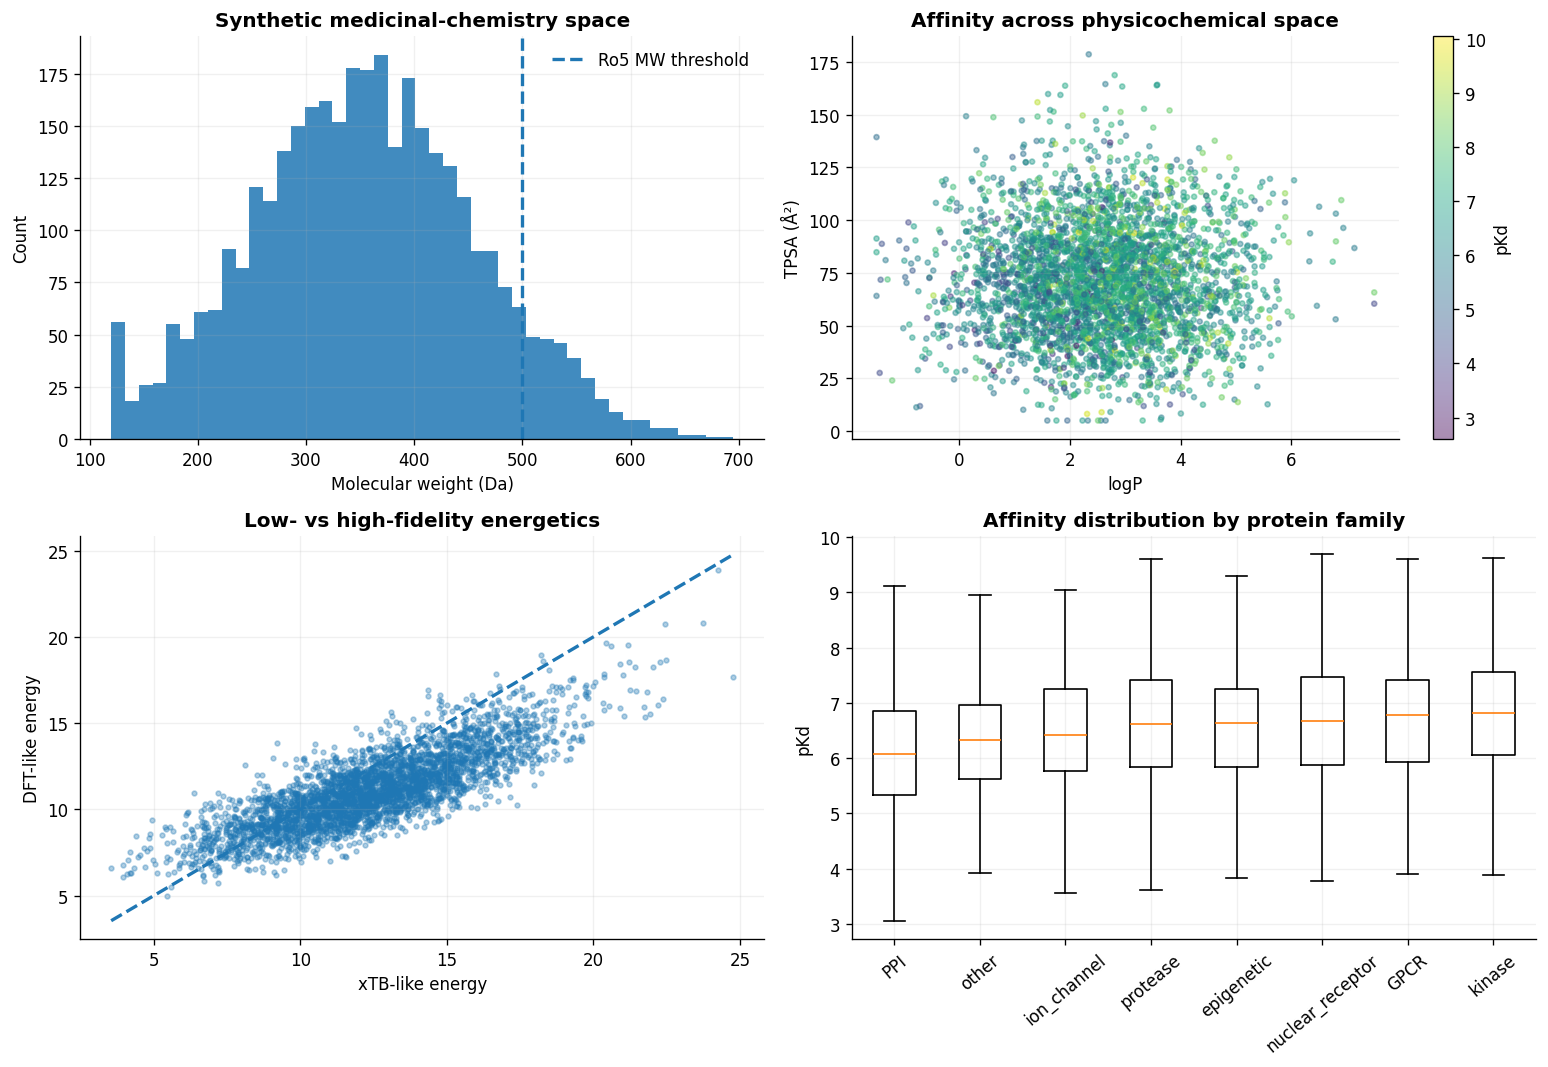

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(df['MW'], bins=45, alpha=0.85)
axes[0,0].axvline(500, ls='--', lw=2, label='Ro5 MW threshold')
axes[0,0].set(xlabel='Molecular weight (Da)', ylabel='Count', title='Synthetic medicinal-chemistry space')
axes[0,0].legend(frameon=False)

sc = axes[0,1].scatter(df['logP'], df['TPSA'], c=df['pKd'], s=9, alpha=0.45, cmap='viridis')
axes[0,1].set(xlabel='logP', ylabel='TPSA (Å²)', title='Affinity across physicochemical space')
fig.colorbar(sc, ax=axes[0,1], label='pKd')

axes[1,0].scatter(df['E_xTB_kcalmol'], df['E_DFT_kcalmol'], s=8, alpha=0.35)
lims = [min(df.E_xTB_kcalmol.min(), df.E_DFT_kcalmol.min()), max(df.E_xTB_kcalmol.max(), df.E_DFT_kcalmol.max())]
axes[1,0].plot(lims, lims, '--', lw=2)
axes[1,0].set(xlabel='xTB-like energy', ylabel='DFT-like energy', title='Low- vs high-fidelity energetics')

family_order = df.groupby('protein_family')['pKd'].median().sort_values().index
axes[1,1].boxplot([df.loc[df.protein_family==f, 'pKd'] for f in family_order], tick_labels=family_order, showfliers=False)
axes[1,1].tick_params(axis='x', rotation=40)
axes[1,1].set(ylabel='pKd', title='Affinity distribution by protein family')

plt.tight_layout()
plt.savefig(OUT/'01_eda_overview.png', bbox_inches='tight')
plt.show()

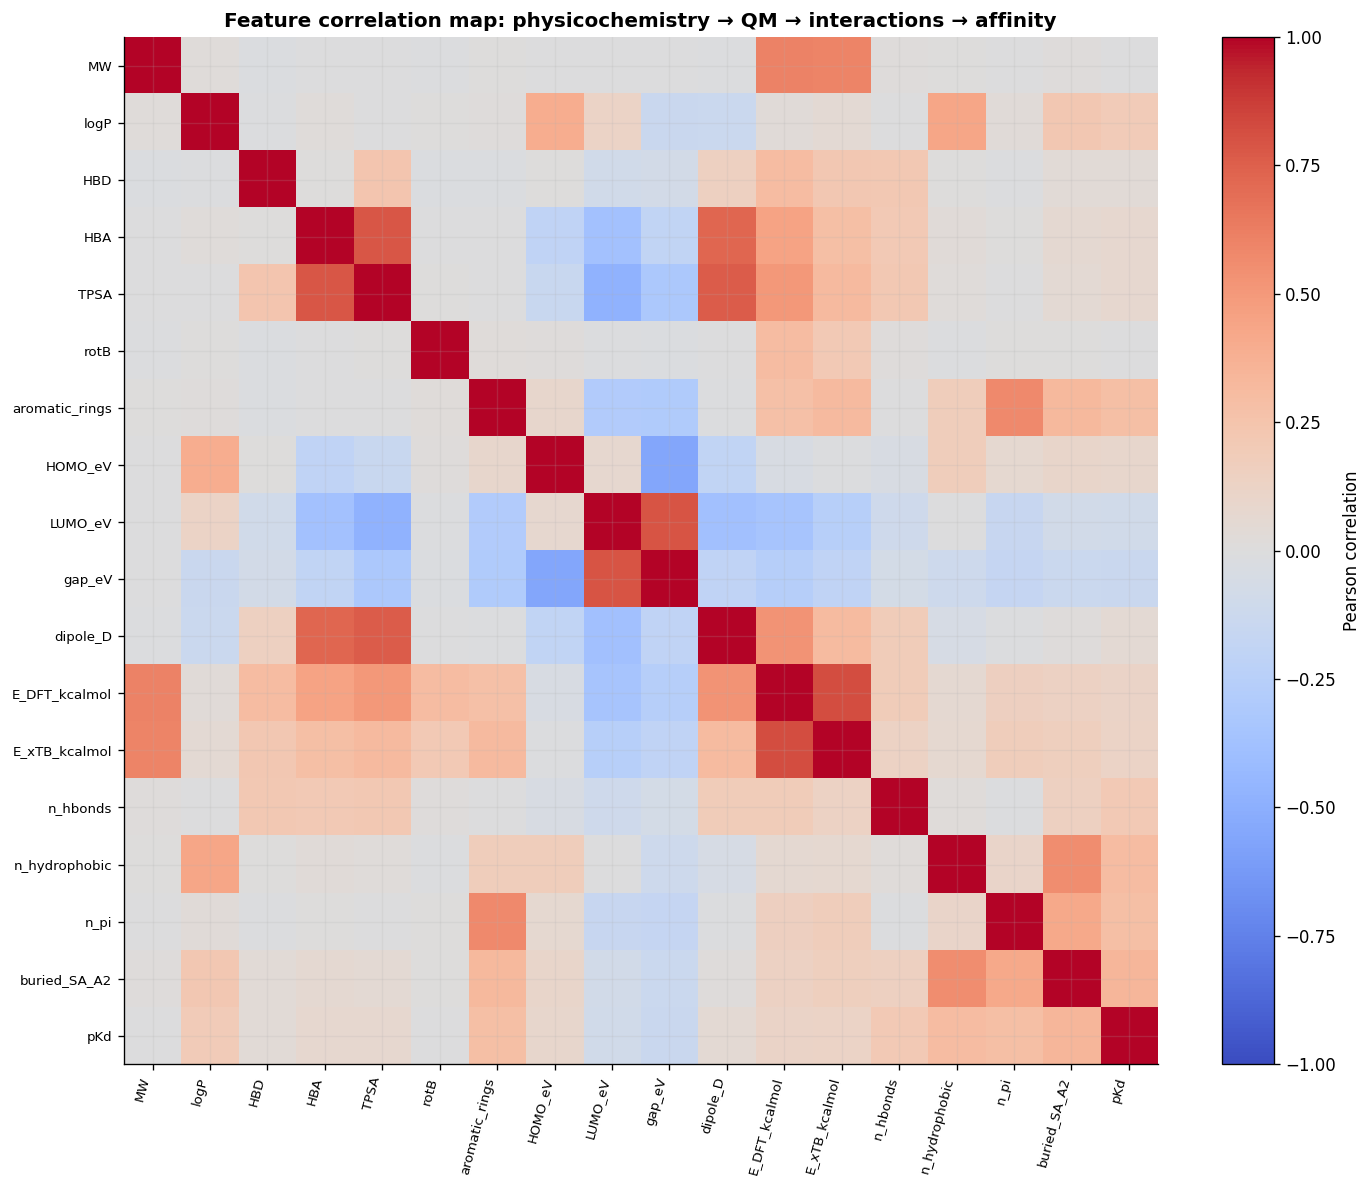

In [5]:
# Correlation structure among major continuous variables
cols = ['MW','logP','HBD','HBA','TPSA','rotB','aromatic_rings','HOMO_eV','LUMO_eV','gap_eV','dipole_D',
        'E_DFT_kcalmol','E_xTB_kcalmol','n_hbonds','n_hydrophobic','n_pi','buried_SA_A2','pKd']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=75, ha='right', fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
ax.set_title('Feature correlation map: physicochemistry → QM → interactions → affinity')
fig.colorbar(im, ax=ax, label='Pearson correlation')
plt.tight_layout()
plt.savefig(OUT/'02_correlation_map.png', bbox_inches='tight')
plt.show()

## 5. Quantum chemistry integration layer

The core notebook stays portable by using synthetic QM values, but a strong production portfolio should demonstrate how real engines would be connected.

The following cell provides **dry-run adapters** for:

- **xTB** command-line calculations,
- **ORCA** input generation,
- **Psi4** Python API,
- **PySCF** Python API.

Nothing is executed unless the relevant software is installed and you explicitly call the function. This separation is useful in regulated or HPC environments because orchestration code can be tested independently of the expensive numerical backend.

In [6]:
def detect_qm_backends():
    backends = {
        'xtb_executable': shutil.which('xtb'),
        'orca_executable': shutil.which('orca'),
    }
    for pkg in ['psi4', 'pyscf', 'jax', 'torch']:
        try:
            __import__(pkg)
            backends[pkg] = 'installed'
        except Exception:
            backends[pkg] = None
    return backends


def xtb_command(xyz_path: str, method='gfn2'):
    flag = '--gfn 2' if method.lower() == 'gfn2' else '--gfn 1'
    return f'xtb {xyz_path} {flag} --opt --json'


def orca_input(xyz_path: str, charge=0, multiplicity=1):
    return f'! B3LYP D3BJ def2-SVP TightSCF Opt\n\n* xyzfile {charge} {multiplicity} {xyz_path}\n'


def psi4_template(xyz_block='0 1\\nO 0 0 0\\nH 0 0 0.96\\nH 0.92 0 -0.24'):
    return ('import psi4\n' +
            'mol = psi4.geometry(\"\"\"' + xyz_block + '\"\"\")\n' +
            "psi4.set_options({'basis':'def2-SVP'})\n" +
            "e, wfn = psi4.energy('B3LYP-D3BJ', molecule=mol, return_wfn=True)\n")


def pyscf_template():
    return ('from pyscf import gto, dft\n' +
            'mol = gto.M(atom=\"O 0 0 0; H 0 0 0.96; H 0.92 0 -0.24\", basis=\"def2-svp\")\n' +
            'mf = dft.RKS(mol); mf.xc = \"b3lyp\"; energy_hartree = mf.kernel()\n')

print(json.dumps(detect_qm_backends(), indent=2))
print('\nExample xTB command:', xtb_command('molecule.xyz'))
print('\nExample ORCA input:\n', orca_input('molecule.xyz'))

{
  "xtb_executable": null,
  "orca_executable": null,
  "psi4": null,
  "pyscf": null,
  "jax": "installed",
  "torch": "installed"
}

Example xTB command: xtb molecule.xyz --gfn 2 --opt --json

Example ORCA input:
 ! B3LYP D3BJ def2-SVP TightSCF Opt

* xyzfile 0 1 molecule.xyz



## 6. Task A — Δ-learning: correct xTB-like energies toward a DFT-like target

A common multi-fidelity strategy is to learn the difference between a cheaper method and a more expensive reference:

\[
\Delta E = E_{DFT} - E_{xTB}
\]

then predict

\[
\hat E_{DFT} = E_{xTB} + \widehat{\Delta E}.
\]

This is attractive in drug discovery because the cheap method can cover much larger chemical space, while a smaller high-level QM set teaches systematic corrections.

In [7]:
qm_features = ['MW','logP','HBD','HBA','TPSA','rotB','aromatic_rings','HOMO_eV','LUMO_eV','gap_eV','dipole_D','E_xTB_kcalmol']
Xq = df[qm_features]
y_delta = df['delta_DFT_minus_xTB']

Xq_train, Xq_test, yd_train, yd_test = train_test_split(Xq, y_delta, test_size=0.20, random_state=SEED)

qm_models = {
    'Ridge': Pipeline([('scale', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=90, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=140, learning_rate=0.06, max_leaf_nodes=31, l2_regularization=0.3, random_state=SEED),
}

qm_results=[]
qm_fitted={}
for name, model in qm_models.items():
    model.fit(Xq_train, yd_train)
    pred_delta = model.predict(Xq_test)
    idx = Xq_test.index
    pred_dft = df.loc[idx, 'E_xTB_kcalmol'].to_numpy() + pred_delta
    true_dft = df.loc[idx, 'E_DFT_kcalmol'].to_numpy()
    qm_results.append({
        'model': name,
        'MAE_kcalmol': mean_absolute_error(true_dft, pred_dft),
        'RMSE_kcalmol': mean_squared_error(true_dft, pred_dft)**0.5,
        'R2': r2_score(true_dft, pred_dft),
    })
    qm_fitted[name]=model

raw_idx = Xq_test.index
raw_mae = mean_absolute_error(df.loc[raw_idx,'E_DFT_kcalmol'], df.loc[raw_idx,'E_xTB_kcalmol'])
qm_results = pd.DataFrame(qm_results).sort_values('MAE_kcalmol')
print('Uncorrected xTB-like MAE:', round(raw_mae,3), 'kcal/mol')
display(qm_results)

Uncorrected xTB-like MAE: 1.8 kcal/mol


,model,MAE_kcalmol,RMSE_kcalmol,R2
0,Ridge,0.445916,0.569689,0.933598
2,HistGradientBoosting,0.493299,0.620654,0.921186
1,RandomForest,0.655081,0.817989,0.863101


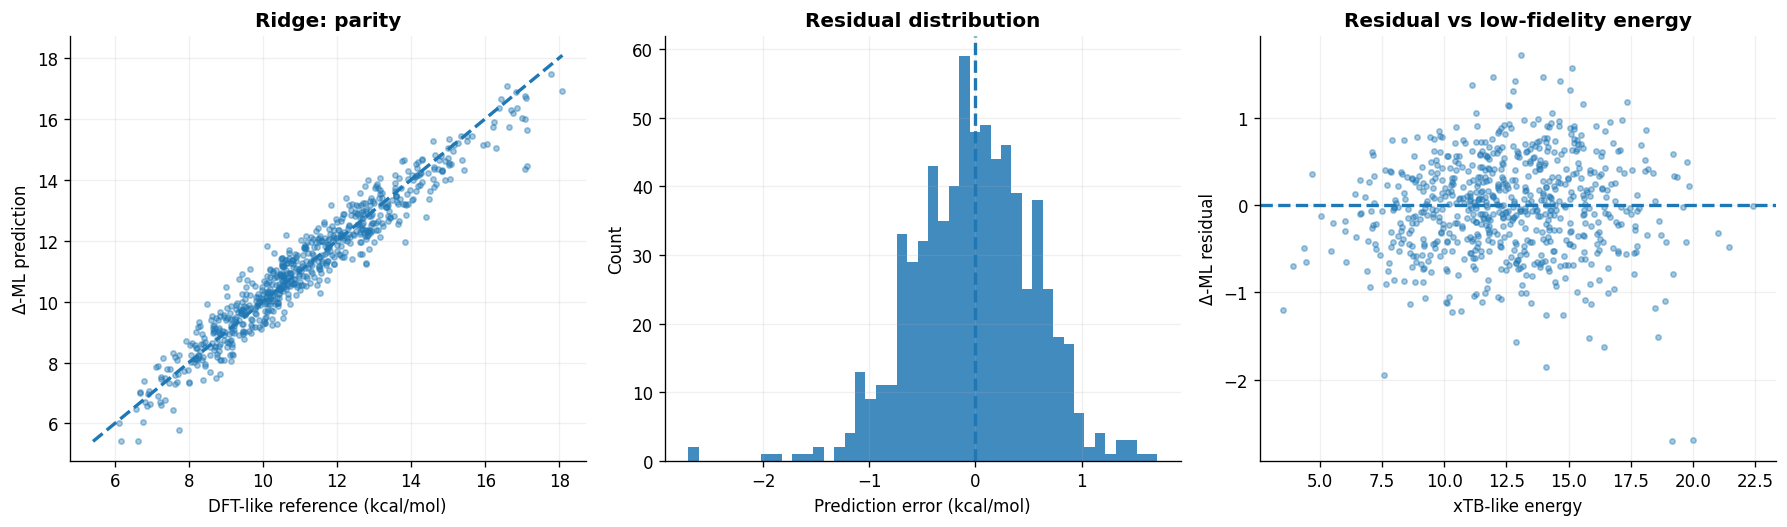

In [8]:
best_qm_name = qm_results.iloc[0]['model']
best_qm = qm_fitted[best_qm_name]
idx = Xq_test.index
pred_delta = best_qm.predict(Xq_test)
pred_dft = df.loc[idx,'E_xTB_kcalmol'].to_numpy() + pred_delta
true_dft = df.loc[idx,'E_DFT_kcalmol'].to_numpy()
resid = pred_dft - true_dft

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(true_dft, pred_dft, s=10, alpha=0.4)
lo=min(true_dft.min(), pred_dft.min()); hi=max(true_dft.max(), pred_dft.max())
axes[0].plot([lo,hi],[lo,hi],'--',lw=2)
axes[0].set(xlabel='DFT-like reference (kcal/mol)', ylabel='Δ-ML prediction', title=f'{best_qm_name}: parity')

axes[1].hist(resid, bins=45, alpha=0.85)
axes[1].axvline(0, ls='--', lw=2)
axes[1].set(xlabel='Prediction error (kcal/mol)', ylabel='Count', title='Residual distribution')

axes[2].scatter(df.loc[idx,'E_xTB_kcalmol'], resid, s=10, alpha=0.4)
axes[2].axhline(0, ls='--', lw=2)
axes[2].set(xlabel='xTB-like energy', ylabel='Δ-ML residual', title='Residual vs low-fidelity energy')

plt.tight_layout()
plt.savefig(OUT/'03_delta_learning.png', bbox_inches='tight')
plt.show()

### Interpretation of Task A

The **raw xTB-like estimate** contains structured method bias. Δ-learning is expected to remove much of that bias because the correction depends on molecular size, aromaticity, polarity and electronic structure.

For a real project, the same architecture can be used with:

- GFN2-xTB as the low-fidelity method,
- a curated B3LYP, ωB97X-D or higher-level QM subset as reference,
- scaffold-aware or chemistry-cluster-aware splitting,
- and uncertainty-triggered selection of the next molecules for expensive QM calculations.

The literature benchmark of **0.34–0.79 kcal/mol MAE** from molecular-energy ML should be treated as context rather than a universal pass criterion because error depends strongly on dataset, geometry source, energy definition, molecular size and split design (PMID: 31142110).

## 7. Task B — Protein–ligand binding affinity prediction with leakage-aware validation

A naive random split can overestimate performance when closely related proteins or ligands appear in both train and test sets. To demonstrate more conservative validation, we hold out **entire protein families** using `GroupShuffleSplit`.

This is deliberately harder than an ordinary IID random split and aligns with recent concerns about PDBbind leakage and generalization.

In [9]:
affinity_features = [
    'MW','logP','HBD','HBA','TPSA','rotB','aromatic_rings',
    'HOMO_eV','LUMO_eV','gap_eV','dipole_D','E_xTB_kcalmol',
    'n_hbonds','n_hydrophobic','n_pi','n_salt_bridges','buried_SA_A2'
]
Xa = df[affinity_features]
ya = df['pKd']
groups = df['protein_family']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr_idx, te_idx = next(splitter.split(Xa, ya, groups=groups))
Xa_train, Xa_test = Xa.iloc[tr_idx], Xa.iloc[te_idx]
ya_train, ya_test = ya.iloc[tr_idx], ya.iloc[te_idx]

print('TRAIN families:', sorted(groups.iloc[tr_idx].unique()))
print('TEST families :', sorted(groups.iloc[te_idx].unique()))
print('Train n:', len(tr_idx), '| Test n:', len(te_idx))

TRAIN families: ['PPI', 'epigenetic', 'ion_channel', 'nuclear_receptor', 'other', 'protease']
TEST families : ['GPCR', 'kinase']
Train n: 2111 | Test n: 1389


In [10]:
aff_models = {
    'Ridge': Pipeline([('scale', StandardScaler()), ('model', Ridge(alpha=2.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=100, min_samples_leaf=4, max_features=0.75, n_jobs=-1, random_state=SEED),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=160, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.5, random_state=SEED),
}

def regression_metrics(y, pred):
    return {
        'MAE': mean_absolute_error(y, pred),
        'RMSE': mean_squared_error(y, pred)**0.5,
        'R2': r2_score(y, pred),
        'Pearson_r': float(np.corrcoef(y, pred)[0,1]),
    }

aff_results=[]
aff_fitted={}
for name, model in aff_models.items():
    model.fit(Xa_train, ya_train)
    pred = model.predict(Xa_test)
    aff_results.append({'model':name, **regression_metrics(ya_test, pred)})
    aff_fitted[name]=model

aff_results = pd.DataFrame(aff_results).sort_values('RMSE')
display(aff_results)

,model,MAE,RMSE,R2,Pearson_r
0,Ridge,0.811005,1.010997,0.168659,0.492441
1,RandomForest,0.830071,1.040478,0.119468,0.444575
2,HistGradientBoosting,0.843487,1.056936,0.091392,0.423702


## 8. PyTorch model: explicitly demonstrate neural-network optimisation

The network uses standardized molecular/QM/interaction descriptors. The purpose is not to claim that a descriptor MLP is superior to modern 3D equivariant GNNs; it is to demonstrate a clean PyTorch training path that can later be replaced by a graph architecture using atomic coordinates and edges.

In [11]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)

scaler = StandardScaler().fit(Xa_train)
Xtr = torch.tensor(scaler.transform(Xa_train), dtype=torch.float32)
Xte = torch.tensor(scaler.transform(Xa_test), dtype=torch.float32)
ytr = torch.tensor(ya_train.to_numpy(), dtype=torch.float32).view(-1,1)
yte = torch.tensor(ya_test.to_numpy(), dtype=torch.float32).view(-1,1)

net = nn.Sequential(
    nn.Linear(Xtr.shape[1], 96), nn.SiLU(), nn.Dropout(0.08),
    nn.Linear(96, 48), nn.SiLU(),
    nn.Linear(48, 24), nn.SiLU(),
    nn.Linear(24, 1)
)

optimizer = torch.optim.AdamW(net.parameters(), lr=2e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()
loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)

history=[]
best_state=None
best_val=float('inf')
patience=8
bad=0

for epoch in range(60):
    net.train()
    train_losses=[]
    for xb, yb in loader:
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(net(xb), yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    net.eval()
    with torch.no_grad():
        val = loss_fn(net(Xte), yte).item()
    history.append((epoch, np.mean(train_losses), val))
    if val < best_val - 1e-5:
        best_val = val
        best_state = {k:v.detach().clone() for k,v in net.state_dict().items()}
        bad=0
    else:
        bad += 1
        if bad >= patience:
            break

net.load_state_dict(best_state)
net.eval()
with torch.no_grad():
    torch_pred = net(Xte).squeeze().numpy()

torch_metrics = {'model':'PyTorch_MLP', **regression_metrics(ya_test, torch_pred)}
aff_results = pd.concat([aff_results, pd.DataFrame([torch_metrics])], ignore_index=True).sort_values('RMSE')
display(aff_results)
print('Epochs trained:', len(history))

,model,MAE,RMSE,R2,Pearson_r
0,Ridge,0.811005,1.010997,0.168659,0.492441
3,PyTorch_MLP,0.807580,1.014316,0.163191,0.455402
1,RandomForest,0.830071,1.040478,0.119468,0.444575
2,HistGradientBoosting,0.843487,1.056936,0.091392,0.423702


Epochs trained: 36


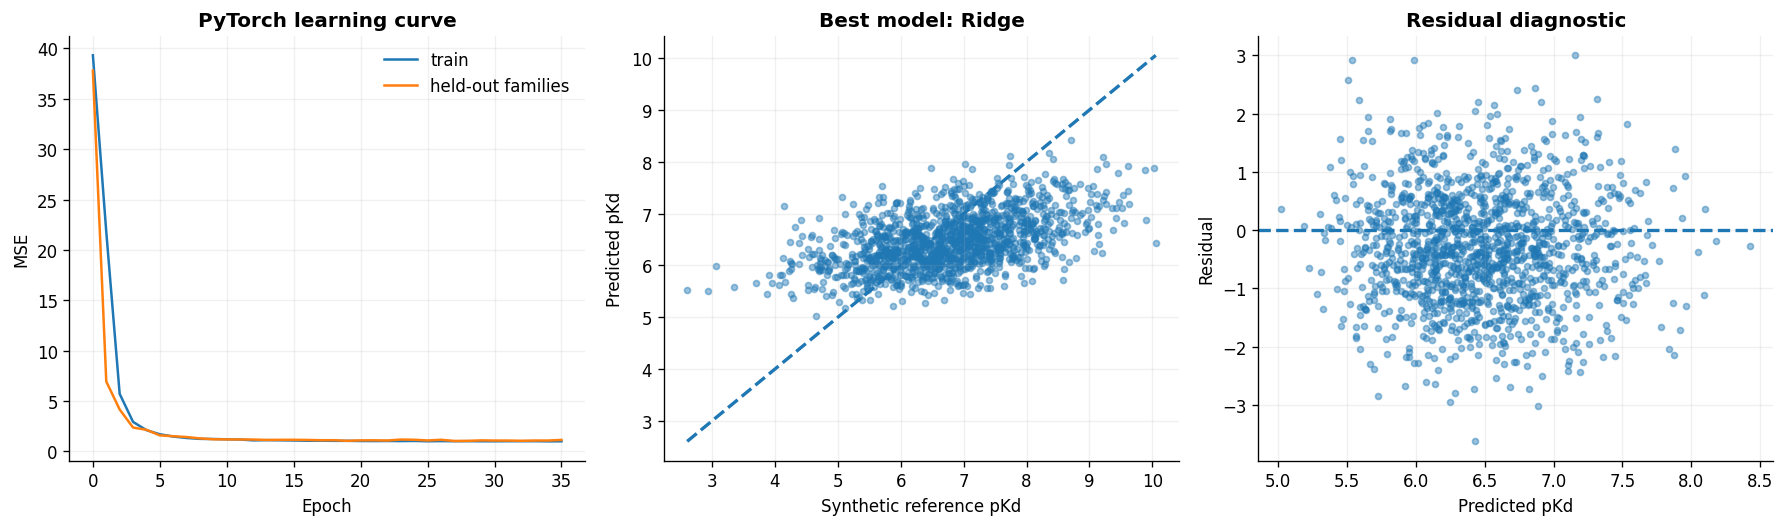

In [12]:
hist = pd.DataFrame(history, columns=['epoch','train_mse','test_mse'])

best_aff_name = aff_results.iloc[0]['model']
if best_aff_name == 'PyTorch_MLP':
    best_pred = torch_pred
else:
    best_pred = aff_fitted[best_aff_name].predict(Xa_test)

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
axes[0].plot(hist.epoch, hist.train_mse, label='train')
axes[0].plot(hist.epoch, hist.test_mse, label='held-out families')
axes[0].set(xlabel='Epoch', ylabel='MSE', title='PyTorch learning curve')
axes[0].legend(frameon=False)

axes[1].scatter(ya_test, best_pred, s=13, alpha=0.45)
lo=min(ya_test.min(), best_pred.min()); hi=max(ya_test.max(), best_pred.max())
axes[1].plot([lo,hi],[lo,hi],'--',lw=2)
axes[1].set(xlabel='Synthetic reference pKd', ylabel='Predicted pKd', title=f'Best model: {best_aff_name}')

res = best_pred - ya_test.to_numpy()
axes[2].scatter(best_pred, res, s=13, alpha=0.45)
axes[2].axhline(0, ls='--', lw=2)
axes[2].set(xlabel='Predicted pKd', ylabel='Residual', title='Residual diagnostic')

plt.tight_layout()
plt.savefig(OUT/'04_affinity_models.png', bbox_inches='tight')
plt.show()

## 9. External benchmark table: do not confuse synthetic performance with experimental benchmark performance

The table below is included so that model performance is interpreted responsibly. A synthetic dataset can be easier or harder than PDBbind depending on how it is generated. The appropriate claim is therefore:

> “This notebook demonstrates the workflow and validation logic. Published PDBbind studies report correlations around 0.82–0.84 and RMSE around 1.2–1.3 pK units under their respective benchmark designs.”

It would be inappropriate to claim that a better number on this synthetic dataset means superiority over those published methods.

In [13]:
literature_benchmarks = pd.DataFrame([
    ['K_DEEP', 2018, 0.82, 1.27, 'PDBbind 2016 core', 'PMID 29309725'],
    ['DeepAtom', 2021, 0.83, 1.23, 'PDBbind 2016 core', 'PMID 33360998'],
    ['RF-Score + ligand descriptors', 2019, 0.821, np.nan, 'PDBbind 2016 core', 'PMID 31598630'],
    ['LGN fusion GNN', 2024, 0.842, np.nan, 'PDBbind 2016 core', 'PMID 38232063'],
], columns=['method','year','Pearson_r','RMSE_pK','benchmark','source'])

display(literature_benchmarks)

,method,year,Pearson_r,RMSE_pK,benchmark,source
0,K_DEEP,2018,0.820,1.27,PDBbind 2016 core,PMID 29309725
1,DeepAtom,2021,0.830,1.23,PDBbind 2016 core,PMID 33360998
2,RF-Score + ligand descriptors,2019,0.821,NaN,PDBbind 2016 core,PMID 31598630
3,LGN fusion GNN,2024,0.842,NaN,PDBbind 2016 core,PMID 38232063


## 10. Uncertainty quantification with a random-forest ensemble

For decision-making, a point prediction is not enough. Here, the variation across trees is used as a simple epistemic-uncertainty proxy. This is not a complete Bayesian treatment, but it supports two practical questions:

1. Are high-uncertainty predictions actually less accurate?
2. Can uncertainty help decide which compounds deserve more expensive computation or experimental follow-up?

,uncertainty_decile,mean_uncertainty,MAE,n
0,0,0.705153,0.814200,139
1,1,0.763736,0.858472,139
2,2,0.791523,0.827501,139
3,3,0.813730,0.830525,139
4,4,0.831956,0.918555,139
5,5,0.851101,0.833369,138
6,6,0.871671,0.732435,139
7,7,0.897690,0.781796,139
8,8,0.934525,0.863945,139
9,9,1.004076,0.839932,139


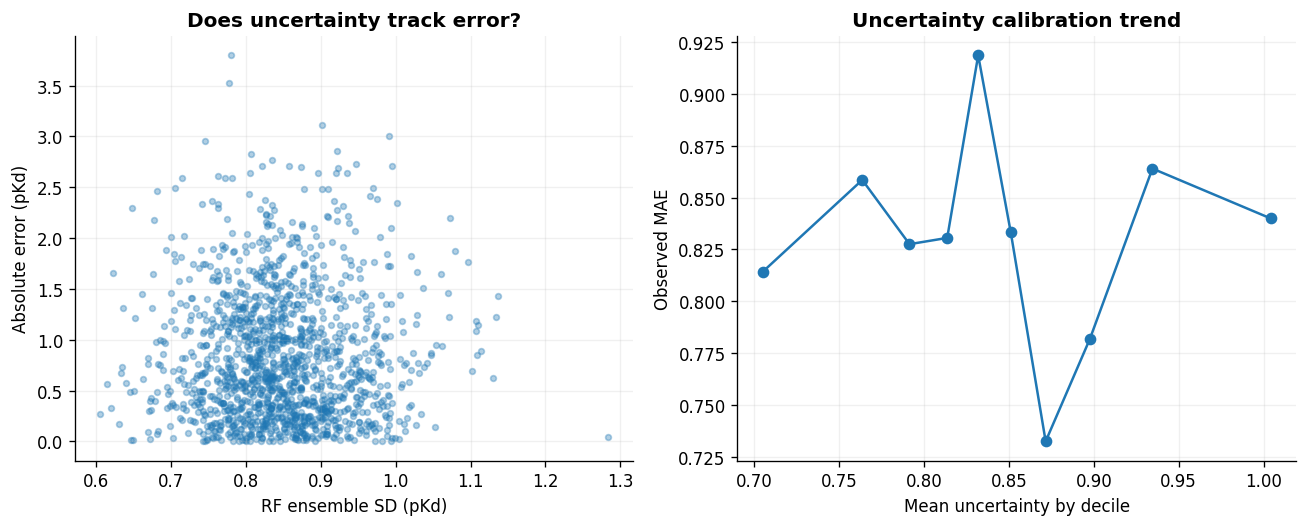

In [14]:
rf = aff_fitted['RandomForest']
# Tree-level predictions for an ensemble uncertainty proxy
all_tree_pred = np.vstack([tree.predict(Xa_test.values) for tree in rf.estimators_])
rf_mean = all_tree_pred.mean(axis=0)
rf_std = all_tree_pred.std(axis=0)
rf_abs_err = np.abs(rf_mean - ya_test.to_numpy())

uq = pd.DataFrame({'pred':rf_mean,'uncertainty':rf_std,'abs_error':rf_abs_err})
uq['uncertainty_decile'] = pd.qcut(uq.uncertainty, 10, labels=False, duplicates='drop')
cal = uq.groupby('uncertainty_decile').agg(mean_uncertainty=('uncertainty','mean'), MAE=('abs_error','mean'), n=('abs_error','size')).reset_index()
display(cal)

fig, axes = plt.subplots(1,2,figsize=(11,4.5))
axes[0].scatter(rf_std, rf_abs_err, s=12, alpha=0.35)
axes[0].set(xlabel='RF ensemble SD (pKd)', ylabel='Absolute error (pKd)', title='Does uncertainty track error?')
axes[1].plot(cal.mean_uncertainty, cal.MAE, marker='o')
axes[1].set(xlabel='Mean uncertainty by decile', ylabel='Observed MAE', title='Uncertainty calibration trend')
plt.tight_layout()
plt.savefig(OUT/'05_uncertainty.png', bbox_inches='tight')
plt.show()

## 11. Explainability: permutation importance

This analysis asks which variables the model actually uses. In a real protein–ligand system, high importance for ligand-only features can be a warning that the model may be learning dataset priors instead of transferable protein–ligand physics. That is why interpretation should be paired with similarity-aware validation.

,feature,importance,sd
16,buried_SA_A2,0.065659,0.003245
6,aromatic_rings,0.052498,0.001188
12,n_hbonds,0.043813,0.007578
1,logP,0.038732,0.003384
13,n_hydrophobic,0.036791,0.005116
14,n_pi,0.032855,0.004021
15,n_salt_bridges,0.024623,0.002558
5,rotB,0.021704,0.000150
3,HBA,0.021277,0.000446
4,TPSA,0.020987,0.001382


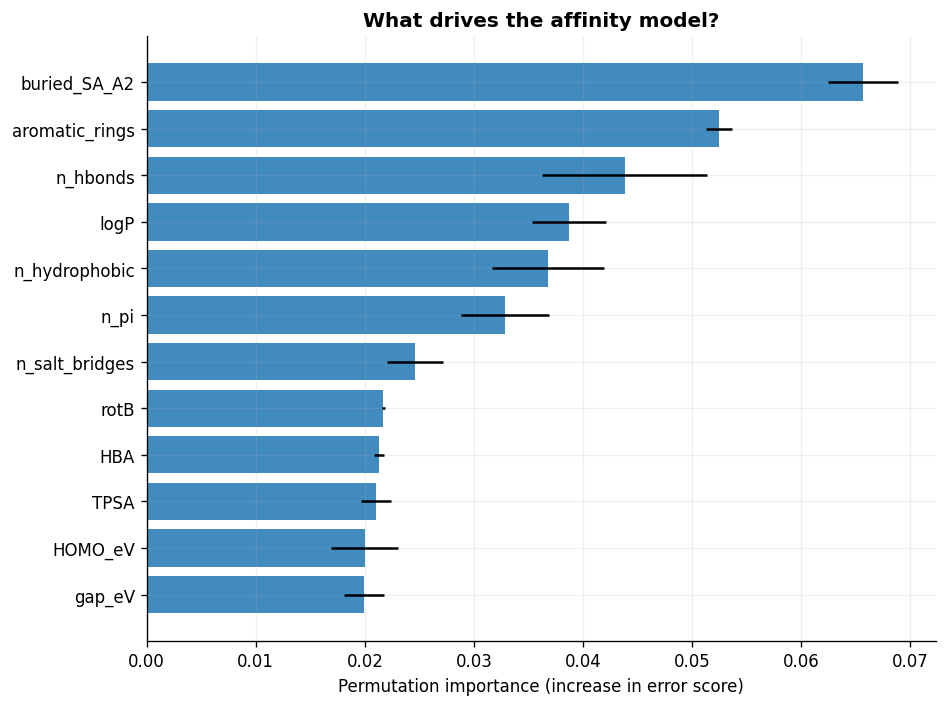

In [15]:
perm = permutation_importance(rf, Xa_test, ya_test, n_repeats=2, random_state=SEED, scoring='neg_root_mean_squared_error', n_jobs=1, max_samples=min(500, len(Xa_test)))
imp = pd.DataFrame({'feature':affinity_features, 'importance':perm.importances_mean, 'sd':perm.importances_std}).sort_values('importance', ascending=False)
display(imp.head(12))

plot_imp = imp.head(12).sort_values('importance')
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(plot_imp.feature, plot_imp.importance, xerr=plot_imp.sd, alpha=0.85)
ax.set(xlabel='Permutation importance (increase in error score)', title='What drives the affinity model?')
plt.tight_layout()
plt.savefig(OUT/'06_permutation_importance.png', bbox_inches='tight')
plt.show()

## 12. Applicability domain / out-of-distribution risk

A useful model should know when a molecule is unlike its training data. We estimate multivariate distance in standardized descriptor space using a regularized Mahalanobis distance.

In production, stronger alternatives include:

- Tanimoto distance on ECFP fingerprints,
- learned latent-space distance,
- conformal prediction,
- ensemble disagreement,
- protein-sequence/structure similarity,
- and explicit scaffold splits.

,bin,mean_distance,MAE,n
0,Q1 in-domain,2.686852,0.845048,278
1,Q2,3.239181,0.785203,278
2,Q3,3.588717,0.839445,277
3,Q4,3.937437,0.804091,278
4,Q5 most OOD,4.613473,0.781342,278


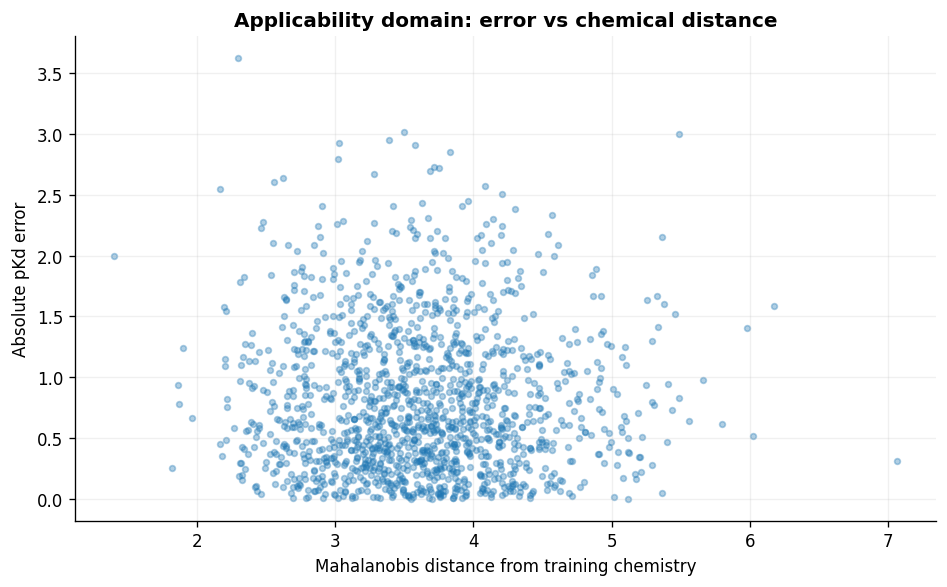

In [16]:
# Regularized Mahalanobis distance to training distribution
Ztr = scaler.transform(Xa_train)
Zte = scaler.transform(Xa_test)
mu = Ztr.mean(axis=0)
cov = np.cov(Ztr, rowvar=False)
reg_cov = cov + 0.12*np.eye(cov.shape[0])
inv_cov = np.linalg.pinv(reg_cov)

def mahal(Z):
    d = Z - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', d, inv_cov, d))

mdist = mahal(Zte)
abs_err = np.abs(best_pred - ya_test.to_numpy())
q = pd.qcut(mdist, 5, labels=['Q1 in-domain','Q2','Q3','Q4','Q5 most OOD'])
ood = pd.DataFrame({'distance':mdist,'abs_error':abs_err,'bin':q})
ood_summary = ood.groupby('bin', observed=True).agg(mean_distance=('distance','mean'), MAE=('abs_error','mean'), n=('abs_error','size')).reset_index()
display(ood_summary)

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(mdist, abs_err, s=12, alpha=0.35)
ax.set(xlabel='Mahalanobis distance from training chemistry', ylabel='Absolute pKd error', title='Applicability domain: error vs chemical distance')
plt.tight_layout()
plt.savefig(OUT/'07_applicability_domain.png', bbox_inches='tight')
plt.show()

## 13. Optional JAX autodiff demonstration

This small section addresses the gap between ordinary predictive ML and differentiable scientific computing. If JAX is installed, it differentiates a toy energy surrogate with respect to molecular descriptors. The same conceptual pattern underlies differentiable physics / chemistry models.

In [17]:
try:
    import jax
    import jax.numpy as jnp

    def toy_energy(x):
        # x = [MW_scaled, logP, gap, dipole]
        return 0.04*x[0] + 0.8*jnp.tanh(x[1]) + 0.15*(x[2]-4.0)**2 + 0.12*x[3]**2

    x = jnp.array([3.5, 2.2, 4.6, 2.8])
    grad = jax.grad(toy_energy)(x)
    print('JAX gradient:', np.asarray(grad))
except Exception as e:
    print('JAX not installed; optional section skipped.')

JAX gradient: [0.04       0.03834011 0.17999998 0.672     ]


## 14. Production engineering: model artifacts, schema, reproducibility

A research notebook becomes more valuable when it exposes a path to deployment. The following cell writes:

- the synthetic dataset,
- benchmark tables,
- model metrics,
- a feature schema,
- a scikit-learn model artifact,
- a PyTorch state dictionary,
- and a configuration manifest.

A production service could load these artifacts behind a FastAPI endpoint, package them in Docker, run CI tests, and submit heavy QM calculations to an HPC scheduler or Kubernetes batch worker.

In [18]:
import joblib

# Save best sklearn affinity model even if PyTorch was numerically best, because it is directly serializable.
best_sklearn_name = aff_results[aff_results.model != 'PyTorch_MLP'].iloc[0]['model']
joblib.dump(aff_fitted[best_sklearn_name], OUT/'affinity_model.joblib')
joblib.dump(best_qm, OUT/'delta_qm_model.joblib')
torch.save({'state_dict': net.state_dict(), 'features': affinity_features}, OUT/'pytorch_affinity_mlp.pt')

qm_results.to_csv(OUT/'qm_delta_model_metrics.csv', index=False)
aff_results.to_csv(OUT/'affinity_model_metrics.csv', index=False)
literature_benchmarks.to_csv(OUT/'literature_benchmarks.csv', index=False)

manifest = {
    'seed': SEED,
    'n_rows': len(df),
    'synthetic_data': True,
    'qm_features': qm_features,
    'affinity_features': affinity_features,
    'grouping_variable': 'protein_family',
    'validation_note': 'Protein-family group holdout used for affinity task.',
    'literature_note': 'Benchmarks are contextual and not direct comparators to synthetic performance.'
}
(OUT/'manifest.json').write_text(json.dumps(manifest, indent=2))

print('Artifacts written:')
for p in sorted(OUT.iterdir()):
    print(' -', p.name)

Artifacts written:
 - 01_eda_overview.png
 - 02_correlation_map.png
 - 03_delta_learning.png
 - 04_affinity_models.png
 - 05_uncertainty.png
 - 06_permutation_importance.png
 - 07_applicability_domain.png
 - affinity_model.joblib
 - affinity_model_metrics.csv
 - delta_qm_model.joblib
 - literature_benchmarks.csv
 - manifest.json
 - pytorch_affinity_mlp.pt
 - qm_delta_model_metrics.csv
 - synthetic_molecular_qm_binding_dataset.csv


## 15. Senior-level QC checks

A strong scientific software project should contain explicit failure checks. These checks detect several common errors:

- accidental target leakage,
- impossible property values,
- duplicated identifiers,
- overlapping protein-family groups between train and test,
- unstable performance tables,
- and missing model artifacts.

In [19]:
# 1. No duplicated molecules.
assert df.molecule_id.is_unique

# 2. No target leakage by direct inclusion of pKd in X.
assert 'pKd' not in affinity_features
assert 'E_DFT_kcalmol' not in qm_features  # DFT target must not leak into Δ prediction features.

# 3. No family overlap between group-held-out train and test.
assert set(groups.iloc[tr_idx]).isdisjoint(set(groups.iloc[te_idx]))

# 4. Basic physics/chemistry sanity.
assert (df.gap_eV > 0).all()
assert (df.MW > 0).all()
assert df.pKd.between(2.5, 12.0).all()

# 5. Metrics finite.
assert np.isfinite(qm_results.select_dtypes('number').to_numpy()).all()
assert np.isfinite(aff_results.select_dtypes('number').to_numpy()).all()

# 6. Artifacts exist.
required = ['affinity_model.joblib','delta_qm_model.joblib','pytorch_affinity_mlp.pt','manifest.json']
assert all((OUT/f).exists() for f in required)

print('QC PASSED: data, leakage controls, metrics, and model artifacts are internally consistent.')

QC PASSED: data, leakage controls, metrics, and model artifacts are internally consistent.


## 16. Interpretation and implications

### Scientific interpretation

**1. Multi-fidelity learning is the central quantum-chemistry idea.**  
The raw xTB-like energies contain a systematic error component. A Δ-model learns chemistry-dependent correction terms instead of relearning the entire energy function. In a real workflow, this can reduce the number of expensive DFT calculations needed to achieve useful accuracy over a defined chemical domain.

**2. Binding prediction needs both chemistry and context.**  
Affinity is driven by a combination of ligand physicochemistry, electronic properties and protein–ligand interaction features. Models that rely only on ligand descriptors can appear predictive because datasets contain strong priors. Therefore, family/scaffold/similarity-aware splits are essential.

**3. Uncertainty is operationally useful.**  
If ensemble uncertainty increases with observed error, high-uncertainty compounds can be routed to higher-level QM, additional docking/MD, or experimental measurement. This converts uncertainty from a diagnostic into an acquisition policy.

**4. Applicability domain matters more than a single headline RMSE.**  
A model may be excellent in familiar chemical space but unreliable for novel chemotypes or protein classes. OOD distance and similarity-aware test design make performance claims more scientifically credible.

### Drug-discovery implication

A mature version of this workflow can support:

```text
millions of enumerated molecules
        ↓
fast descriptors / GFN2-xTB
        ↓
uncertainty-aware Δ-ML correction
        ↓
protein–ligand model / docking / 3D GNN
        ↓
rank by affinity + uncertainty + developability
        ↓
select a small set for DFT / free-energy / experiment
        ↓
feed new measurements back into active learning
```

### What would make the portfolio project even stronger

For a true Roche/Genentech AI4DD-level follow-on version, replace the synthetic layer with public real data and add:

- QM9 / PC9 or another public QM dataset,
- PDBbind / BindingDB-derived affinity data under licence/usage conditions,
- RDKit ECFP and 3D conformers,
- PyTorch Geometric or an equivariant architecture,
- real GFN2-xTB calculations,
- a DFT subset from Psi4/PySCF/ORCA,
- scaffold and sequence-similarity splits,
- conformal uncertainty,
- experiment tracking,
- Docker + CI,
- and a FastAPI inference / batch-QM orchestration service.

The major portfolio message is therefore not “I trained one model.” It is:

> **I can design a scientifically defensible, multi-fidelity molecular-ML workflow that connects quantum chemistry, protein–ligand modelling, uncertainty, validation and deployable software.**

## 17. References — peer-reviewed journal articles indexed in PubMed

1. **Valdés JJ, Tchagang AB.** Novel machine learning insights into the QM7b and QM9 quantum mechanics datasets. *J Comput Chem.* 2024;45:1193–1214. PMID: **38329198**. DOI: https://doi.org/10.1002/jcc.27295  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/38329198/

2. **Nandi S, Vegge T, Bhowmik A.** MultiXC-QM9: Large dataset of molecular and reaction energies from multi-level quantum chemical methods. *Sci Data.* 2023;10:783. PMID: **37938558**. DOI: https://doi.org/10.1038/s41597-023-02690-2  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/37938558/

3. **[JCTC molecular-energy study].** Predicting Molecular Energy Using Force-Field Optimized Geometries and Atomic Vector Representations Learned from an Improved Deep Tensor Neural Network. *J Chem Theory Comput.* 2019. PMID: **31142110**. DOI: https://doi.org/10.1021/acs.jctc.9b00001  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/31142110/

4. **Jiménez J, Skalic M, Martínez-Rosell G, De Fabritiis G.** K_DEEP: Protein-Ligand Absolute Binding Affinity Prediction via 3D-Convolutional Neural Networks. *J Chem Inf Model.* 2018. PMID: **29309725**.  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/29309725/

5. **DeepAtom: Deep Learning in Drug Design: Protein-Ligand Binding Affinity Prediction.** PMID: **33360998**.  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/33360998/

6. **Boyles F, Deane CM, Morris GM.** Learning from the ligand: using ligand-based features to improve binding affinity prediction. *Bioinformatics.* 2019. PMID: **31598630**.  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/31598630/

7. **Guo J.** Improving structure-based protein-ligand affinity prediction by graph representation learning and ensemble learning. *PLoS One.* 2024;19:e0296676. PMID: **38232063**. DOI: https://doi.org/10.1371/journal.pone.0296676  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/38232063/

8. **Leak Proof PDBBind: A Reorganized Data Set of Protein-Ligand Complexes for More Generalizable Binding Affinity Prediction.** PMID: **41486605**.  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/41486605/

9. **Baell J, Congreve M, Leeson P, Abad-Zapatero C.** Ask the experts: past, present and future of the rule of five. *Future Med Chem.* 2013;5:745–752. PMID: **23651089**. DOI: https://doi.org/10.4155/fmc.13.61  
   PubMed: https://pubmed.ncbi.nlm.nih.gov/23651089/

10. **Lipinski CA.** Rule of five in 2015 and beyond. *Adv Drug Deliv Rev.* 2016;101:34–41. PMID: **27154268**. DOI: https://doi.org/10.1016/j.addr.2016.04.029  
    PubMed: https://pubmed.ncbi.nlm.nih.gov/27154268/

11. **dxtb—An efficient and fully differentiable framework for extended tight-binding.** PMID: **39120026**.  
    PubMed: https://pubmed.ncbi.nlm.nih.gov/39120026/

12. **Q-DFTNet: A Chemistry-Informed Neural Network Framework for Predicting Molecular Dipole Moments via DFT-Driven QM9 Data.** *J Comput Chem.* 2025. PMID: **40801135**. DOI: https://doi.org/10.1002/jcc.70206  
    PubMed: https://pubmed.ncbi.nlm.nih.gov/40801135/

---

### Reproducibility note

The simulation seed is fixed. All synthetic assumptions are visible in code. Published benchmark values are kept separate from synthetic model outputs. This separation is essential for honest scientific communication.